In [1]:
import os
os.chdir('../')

In [2]:
import random
import numpy as np
import torch
import os

SEED = 42
def seed_set(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

seed_set(SEED)

In [3]:
# %load modules/data_handler.py
import numpy as np
import pandas as pd

import torch
from torch_geometric.data import Dataset, InMemoryDataset, Data
from torch_geometric.loader import DataLoader
from torch_geometric.utils import from_smiles
from torch_geometric.utils import degree

import os
from tqdm.notebook import tqdm

import deepchem as dc

from rdkit import Chem
from rdkit.Chem import AllChem

from sklearn.model_selection import train_test_split

from molfeat.calc import FPCalculator, RDKitDescriptors2D, Pharmacophore2D, Pharmacophore3D, RDKitDescriptors3D
import datamol as dm
from molfeat.trans import MoleculeTransformer

from sklearn.decomposition import PCA

import signal

from rdkit.Chem.Scaffolds import MurckoScaffold
from collections import defaultdict



def generate_graph_list(df, smiles_column, target_column):
    graph_list = []

    for i, smile in tqdm(enumerate(df[smiles_column])):
        g = from_smiles(smile)
        g.x = g.x.float()
        y = torch.tensor(df[target_column][i], dtype=torch.float).view(1, -1)
        g.y = y
        graph_list.append(g)

    return graph_list



############################# General Loader : #############################

def load_and_process_data(dataset, splitter="random", test_size=0.1, batch_size=32):
    """
    Loads a dataset, splits it into train, validation, and test sets, and creates PyTorch Geometric data loaders.
    """
    if splitter == "random":
        
        data_size = len(dataset)
        train_idx, test_idx = train_test_split(list(range(data_size)), test_size=0.1)
        train_idx, valid_idx = train_test_split(train_idx, test_size = test_size)  # Split train further into train and valid

        # Create data loaders for train, validation, and test sets
        train_loader = DataLoader(dataset[train_idx], batch_size=batch_size, shuffle=True)
        val_loader = DataLoader(dataset[valid_idx], batch_size=batch_size, shuffle=False)
        test_loader = DataLoader(dataset[test_idx], batch_size=batch_size, shuffle=False)

    else:
        raise ValueError(f"Invalid splitter type: {splitter}. Valid options are 'random' or 'scaffold'.")

    return train_loader, val_loader, test_loader



def generate_scaffold(smiles, include_chirality=False):
    """Generate the Bemis-Murcko scaffold for a given SMILES string."""
    mol = Chem.MolFromSmiles(smiles)
    scaffold = MurckoScaffold.MurckoScaffoldSmiles(
        mol=mol, includeChirality=include_chirality)
    return scaffold


def scaffold_split_indices(smiles_list, frac_train=0.8, frac_valid=0.1, frac_test=0.1, seed=None, include_chirality=False):
    """
    Perform scaffold splitting on a list of SMILES strings and return the indices for train, validation, and test sets.

    Args:
        smiles_list (list): List of SMILES strings.
        frac_train (float): Fraction of the dataset to use for training.
        frac_valid (float): Fraction of the dataset to use for validation.
        frac_test (float): Fraction of the dataset to use for testing.
        seed (int): Random seed for shuffling the scaffolds.
        include_chirality (bool): Whether to include chirality in scaffold generation.

    Returns:
        dict: Dictionary with train, valid, and test indices as torch tensors.
    """
    np.testing.assert_almost_equal(frac_train + frac_valid + frac_test, 1.0, err_msg="The fractions must sum to 1.")
    
    # Set random seed for reproducibility
    rng = np.random.RandomState(seed)
    
    # Group SMILES by their scaffold
    scaffolds = defaultdict(list)
    for ind, smiles in enumerate(smiles_list):
        scaffold = generate_scaffold(smiles, include_chirality)
        scaffolds[scaffold].append(ind)
    
    # Get scaffold keys and shuffle them
    scaffold_keys = list(scaffolds.keys())
    rng.shuffle(scaffold_keys)
    
    # Compute the number of samples for each set
    n_total = len(smiles_list)
    n_total_valid = int(np.floor(frac_valid * n_total))
    n_total_test = int(np.floor(frac_test * n_total))
    
    train_index = []
    valid_index = []
    test_index = []
    
    # Distribute the scaffold sets into train, valid, and test sets
    for scaffold_key in scaffold_keys:
        scaffold_set = scaffolds[scaffold_key]
        if len(valid_index) + len(scaffold_set) <= n_total_valid:
            valid_index.extend(scaffold_set)
        elif len(test_index) + len(scaffold_set) <= n_total_test:
            test_index.extend(scaffold_set)
        else:
            train_index.extend(scaffold_set)
    
    # Return indices as torch tensors in a dictionary
    return {
        'train': torch.tensor(train_index, dtype=torch.long),
        'valid': torch.tensor(valid_index, dtype=torch.long),
        'test': torch.tensor(test_index, dtype=torch.long)
    }
    
    
class FingerprintsDescriptorsCalculator:
    def __init__(self, smiles_column):
        self.smiles_column = smiles_column
        
        self.valid_molecules = []
        self.valid_smiles = []
        self.invalid_indices = []

        for index, smiles in tqdm(enumerate(self.smiles_column)) :
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                print('******* Invalid Mol !!!!!!!')
                self.invalid_indices.append(index)
            else :
                self.valid_smiles.append(smiles)


        self.calc_ecfp = FPCalculator("ecfp")
        self.calc_topological = FPCalculator("topological")
        self.calc_maccs = FPCalculator("maccs")
        self.calc_estate = FPCalculator("estate")
        self.calc_rdkit2D = RDKitDescriptors2D(replace_nan=True)
        self.calc_phar2D = Pharmacophore2D()
      

        self.featurizer_ecfp = MoleculeTransformer(self.calc_ecfp, dtype=np.float64)
        self.featurizer_topological = MoleculeTransformer(self.calc_topological, dtype=np.float64)
        self.featurizer_maccs = MoleculeTransformer(self.calc_maccs, dtype=np.float64)
        self.featurizer_estate = MoleculeTransformer(self.calc_estate, dtype=np.float64)
        self.featurizer_rdkit2D = MoleculeTransformer(self.calc_rdkit2D, dtype=np.float64)
        self.featurizer_phar2D = MoleculeTransformer(self.calc_phar2D, dtype=np.float64)
        

    def calculate_ecfp(self):
        with dm.without_rdkit_log():
            return self.featurizer_ecfp(self.valid_smiles)

    def calculate_topological(self):
        with dm.without_rdkit_log():
            return self.featurizer_topological(self.valid_smiles)

    def calculate_maccs(self):
        with dm.without_rdkit_log():
            return self.featurizer_maccs(self.valid_smiles)

    def calculate_estate(self):
        with dm.without_rdkit_log():
            return self.featurizer_estate(self.valid_smiles)

    def calculate_rdkit2D(self):
        with dm.without_rdkit_log():
            return self.featurizer_rdkit2D(self.valid_smiles)

    def calculate_phar2D(self):
        with dm.without_rdkit_log():
            return self.featurizer_phar2D(self.valid_smiles)
    
    def get_invalid_indices(self):
        return self.invalid_indices

    def get_valid_smiles(self):
        return self.valid_smiles


# Usage Example :
# df = pd.read_csv('/content/bace.csv')
# smiles_column = df['mol'].values

# calculator = FingerprintsDescriptorsCalculator(smiles_column)

# ecfp = calculator.calculate_ecfp()
# topological = calculator.calculate_topological()
# maccs = calculator.calculate_maccs()
# estate = calculator.calculate_estate()
# rdkit2D = calculator.calculate_rdkit2D()
# phar2D = calculator.calculate_phar2D()

# phar3D = calculator.calculate_phar3D()
# rdkit3D = calculator.calculate_rdkit3D()
# invalid_indices = calculator.get_invalid_indices()


class FingerprintsDescriptorsCalculator2:
    def __init__(self, smiles_column):
        self.smiles_column = smiles_column
        
        self.valid_smiles = []
        self.invalid_indices = []

        for index, smiles in tqdm(enumerate(self.smiles_column)):
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                print(f'******* Invalid Mol at index {index} !!!!!!')
                self.invalid_indices.append(index)
            else:
                self.valid_smiles.append(smiles)

        self.calc_ecfp = FPCalculator("ecfp")
        self.calc_topological = FPCalculator("topological")
        self.calc_maccs = FPCalculator("maccs")
        self.calc_estate = FPCalculator("estate")
        self.calc_rdkit2D = RDKitDescriptors2D(replace_nan=True)
        self.calc_phar2D = Pharmacophore2D(replace_nan=True)

        self.featurizer_ecfp = MoleculeTransformer(self.calc_ecfp, dtype=np.float64)
        self.featurizer_topological = MoleculeTransformer(self.calc_topological, dtype=np.float64)
        self.featurizer_maccs = MoleculeTransformer(self.calc_maccs, dtype=np.float64)
        self.featurizer_estate = MoleculeTransformer(self.calc_estate, dtype=np.float64)
        self.featurizer_rdkit2D = MoleculeTransformer(self.calc_rdkit2D, dtype=np.float64)
        # self.featurizer_phar2D = MoleculeTransformer(self.calc_phar2D, dtype=np.float64)

    def calculate_phar2D(self, timeout=20):
        def timeout_handler(signum, frame):
            raise TimeoutError("Phar2D calculation timed out")

        signal.signal(signal.SIGALRM, timeout_handler)

        results = []
        remaining_smiles = []
        for index, smiles in tqdm(enumerate(self.valid_smiles)):
            signal.alarm(timeout)
            try:
                with dm.without_rdkit_log():
                    result = self.calc_phar2D(smiles)
                results.append(result)
                remaining_smiles.append(smiles)
            except TimeoutError:
                print(f"Phar2D calculation timed out for index {index}, smiles: {smiles}")
                self.invalid_indices.append(index)
            finally:
                signal.alarm(0)

        self.valid_smiles = remaining_smiles
        return np.array(results, dtype=np.float64)

    def calculate_ecfp(self):
        with dm.without_rdkit_log():
            return self.featurizer_ecfp(self.valid_smiles)

    def calculate_topological(self):
        with dm.without_rdkit_log():
            return self.featurizer_topological(self.valid_smiles)

    def calculate_maccs(self):
        with dm.without_rdkit_log():
            return self.featurizer_maccs(self.valid_smiles)

    def calculate_estate(self):
        with dm.without_rdkit_log():
            return self.featurizer_estate(self.valid_smiles)

    def calculate_rdkit2D(self):
        with dm.without_rdkit_log():
            return self.featurizer_rdkit2D(self.valid_smiles)

    def get_invalid_indices(self):
        return self.invalid_indices

    def get_valid_smiles(self):
        return self.valid_smiles


# calculator = FingerprintsDescriptorsCalculator2(smiles_column)

# phar2D = calculator.calculate_phar2D()
# ecfp = calculator.calculate_ecfp()
# topological = calculator.calculate_topological()
# maccs = calculator.calculate_maccs()
# estate = calculator.calculate_estate()
# rdkit2D = calculator.calculate_rdkit2D()
# invalid_indices = calculator.get_invalid_indices()



class PCAReducer:
    def __init__(self, n_components=64):
        self.n_components = n_components
        self.pca_ecfp = PCA(n_components=self.n_components)
        self.pca_topological = PCA(n_components=self.n_components)
        self.pca_maccs = PCA(n_components=self.n_components)
        self.pca_estate = PCA(n_components=self.n_components)
        self.pca_rdkit2D = PCA(n_components=self.n_components)
        self.pca_phar2D = PCA(n_components=self.n_components)
        # self.pca_phar3D = PCA(n_components=self.n_components)
        # self.pca_rdkit3D = PCA(n_components=self.n_components)


    def reduce_ecfp(self, ecfp_data):
        return self.pca_ecfp.fit_transform(ecfp_data)

    def reduce_topological(self, topological_data):
        return self.pca_topological.fit_transform(topological_data)

    def reduce_maccs(self, maccs_data):
        return self.pca_maccs.fit_transform(maccs_data)

    def reduce_estate(self, estate_data):
        return self.pca_estate.fit_transform(estate_data)

    def reduce_rdkit2D(self, rdkit2D_data):
        return self.pca_rdkit2D.fit_transform(rdkit2D_data)

    def reduce_phar2D(self, phar2D_data):
        return self.pca_phar2D.fit_transform(phar2D_data)

    def reduce_phar3D(self, phar3D_data):
        return self.pca_phar3D.fit_transform(phar3D_data)

    def reduce_rdkit3D(self, rdkit3D_data):
        return self.pca_rdkit3D.fit_transform(rdkit3D_data)

# Usage Example :
# N_COMPONENTS = 64
# reducer = PCAReducer(n_components=N_COMPONENTS)

# ecfp_reduced = reducer.reduce_ecfp(ecfp)
# topological_reduced = reducer.reduce_topological(topological)
# maccs_reduced = reducer.reduce_maccs(maccs)
# estate_reduced = reducer.reduce_estate(estate)
# rdkit2D_reduced = reducer.reduce_rdkit2D(rdkit2D)
# phar2D_reduced = reducer.reduce_phar2D(phar2D)

# phar3D_reduced = reducer.reduce_phar3D(phar3D)
# rdkit3D_reduced = reducer.reduce_rdkit3D(rdkit3D)


class DTsetBasic(InMemoryDataset):
    def __init__(self, root, filename, smiles_column, label_column,
                 ECFP, Topological, MACCS, EState, Rdkit2D, Phar2D):
        self.filename = filename
        self.smiles_column = smiles_column
        # Allow label_column to be string or list of one string
        self.label_column = [label_column] if isinstance(label_column, str) else label_column

        self.ECFP = ECFP
        self.Topological = Topological
        self.MACCS = MACCS
        self.EState = EState
        self.Rdkit2D = Rdkit2D
        self.Phar2D = Phar2D

        super().__init__(root)
        self.load(self.processed_paths[0])

    @property
    def raw_file_names(self):
        return [self.filename]

    @property
    def processed_file_names(self):
        return ['data.pt']

    def download(self):
        pass

    def process(self):
        data_path = os.path.join(self.raw_dir, self.filename)
        df = pd.read_csv(data_path)

        graph_list = []
        for i, smiles in tqdm(enumerate(df[self.smiles_column]), desc="Processing SMILES"):
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                continue

            g = from_smiles(smiles)
            g.x = g.x.float()

            # Extract label(s) — now always list
            label_vals = df.loc[i, self.label_column].values.astype(np.float32)
            g.y = torch.tensor(label_vals, dtype=torch.float).view(1, -1)  # Shape: [1, num_tasks=1]

            # Optional: Warn if NaN
            if torch.isnan(g.y).any():
                print(f"⚠️  NaN label at index {i} for SMILES: {smiles}")

            g.ECFP = torch.tensor(self.ECFP[i], dtype=torch.float).view(1, -1)
            g.Topological = torch.tensor(self.Topological[i], dtype=torch.float).view(1, -1)
            g.MACCS = torch.tensor(self.MACCS[i], dtype=torch.float).view(1, -1)
            g.EState = torch.tensor(self.EState[i], dtype=torch.float).view(1, -1)
            g.Rdkit2D = torch.tensor(self.Rdkit2D[i], dtype=torch.float).view(1, -1)
            g.Phar2D = torch.tensor(self.Phar2D[i], dtype=torch.float).view(1, -1)

            graph_list.append(g)

        data_list = graph_list

        if self.pre_filter is not None:
            data_list = [data for data in data_list if self.pre_filter(data)]
        if self.pre_transform is not None:
            data_list = [self.pre_transform(data) for data in data_list]

        self.save(data_list, self.processed_paths[0])

# dataset_64 = DTsetBasic(root='basic-64', filename='bace.csv', smiles_column='mol', label_column='Class',
#     ECFP=ecfp_reduced, Topological=topological_reduced, MACCS=maccs_reduced,
#     EState=estate_reduced, Rdkit2D=rdkit2D_reduced, Phar2D=phar2D_reduced)



class DTsetBasicMulti(InMemoryDataset):
    def __init__(self, root, filename, smiles_column, label_columns,
                 ECFP, Topological, MACCS, EState, Rdkit2D, Phar2D):
        self.filename = filename
        self.smiles_column = smiles_column

        # اطمینان از اینکه label_columns حتماً یک لیست است
        self.label_columns = label_columns if isinstance(label_columns, list) else [label_columns]

        self.ECFP = ECFP
        self.Topological = Topological
        self.MACCS = MACCS
        self.EState = EState
        self.Rdkit2D = Rdkit2D
        self.Phar2D = Phar2D

        super().__init__(root)
        self.load(self.processed_paths[0])

    @property
    def raw_file_names(self):
        return [self.filename]

    @property
    def processed_file_names(self):
        return ['data.pt']

    def download(self):
        pass

    def process(self):
        data_path = os.path.join(self.raw_dir, self.filename)
        df = pd.read_csv(data_path)

        # Get all label columns: everything except smiles_column
        label_columns = [col for col in df.columns if col != self.smiles_column]

        graph_list = []
        for i, smiles in tqdm(enumerate(df[self.smiles_column]), desc="Processing SMILES"):
            mol = Chem.MolFromSmiles(smiles)
            if mol is None:
                continue

            g = from_smiles(smiles)
            g.x = g.x.float()

            # Extract all task labels
            # label_vals = df.loc[i, label_columns].values.astype(np.float32)

            # تغییر 2: استفاده از self.label_columns به جای استخراج اتوماتیک
            label_vals = df.loc[i, self.label_columns].values.astype(np.float32)
            g.y = torch.tensor(label_vals, dtype=torch.float).view(1, -1)  # Shape: [1, num_tasks]

            # Optional: Log if all labels missing
            if torch.isnan(g.y).all():
                print(f"⚠️  All labels NaN at index {i} for SMILES: {smiles}")

            g.ECFP = torch.tensor(self.ECFP[i], dtype=torch.float).view(1, -1)
            g.Topological = torch.tensor(self.Topological[i], dtype=torch.float).view(1, -1)
            g.MACCS = torch.tensor(self.MACCS[i], dtype=torch.float).view(1, -1)
            g.EState = torch.tensor(self.EState[i], dtype=torch.float).view(1, -1)
            g.Rdkit2D = torch.tensor(self.Rdkit2D[i], dtype=torch.float).view(1, -1)
            g.Phar2D = torch.tensor(self.Phar2D[i], dtype=torch.float).view(1, -1)

            graph_list.append(g)

        data_list = graph_list

        if self.pre_filter is not None:
            data_list = [data for data in data_list if self.pre_filter(data)]
        if self.pre_transform is not None:
            data_list = [self.pre_transform(data) for data in data_list]

        self.save(data_list, self.processed_paths[0])

No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
No normalization for NumAmideBonds. Feature removed!
No normalization for NumAtomStereoCenters. Feature removed!
No normalization for NumBridgeheadAtoms. Feature removed!
No normalization for NumHeterocycles. Feature removed!
No normalization for NumSpiroAtoms. Feature removed!
No normalization for NumUnspecifiedAtomStereoCenters. Feature removed!
No normalization for Phi. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with transformers dependency. No module named 'transformers'
cannot import name 'HuggingFaceModel' from 'deepchem.models.torch_models' (d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\deepchem\models\torch_models\__init__.py)
Skipped loading modules with pytorch-lightning dependency, missing 

In [4]:
from modules.data_handler import FingerprintsDescriptorsCalculator

In [5]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA

class PCAReducer:
    def __init__(self, n_components=64):
        self.n_components = n_components
        self.models = {
            "ecfp": PCA(n_components),
            "topological": PCA(n_components),
            "maccs": PCA(n_components),
            "estate": PCA(n_components),
            "rdkit2D": PCA(n_components),
            "phar2D": PCA(n_components)
        }
        self.explained_variance = {}

    def reduce(self, name, data):
        pca = self.models[name]
        reduced = pca.fit_transform(data)

        cumulative = np.cumsum(pca.explained_variance_ratio_)
        self.explained_variance[name] = {
            "explained_variance_ratio": pca.explained_variance_ratio_,
            "cumulative_explained_variance": cumulative
        }

        return reduced


def process_dataset_with_pca(dataset_path, smiles_column_name, n_components):
    df = pd.read_csv(dataset_path)
    smiles_column = df[smiles_column_name].values

    # Compute fingerprints & descriptors
    calc = FingerprintsDescriptorsCalculator(smiles_column)

    ecfp = calc.calculate_ecfp()
    topological = calc.calculate_topological()
    maccs = calc.calculate_maccs()
    estate = calc.calculate_estate()
    rdkit2D = calc.calculate_rdkit2D()
    phar2D = calc.calculate_phar2D()

    reducer = PCAReducer(n_components)

    reduced = {
        "ecfp": reducer.reduce("ecfp", ecfp),
        "topological": reducer.reduce("topological", topological),
        "maccs": reducer.reduce("maccs", maccs),
        "estate": reducer.reduce("estate", estate),
        "rdkit2D": reducer.reduce("rdkit2D", rdkit2D),
        "phar2D": reducer.reduce("phar2D", phar2D)
    }

    return reduced, reducer.explained_variance


In [6]:
datasets = {
    "bace":        ("data/datasets/bace.csv", "mol"),      
    "bbbp":        ("data/datasets/BBBP.csv", "smiles"),
    "clintox":     ("data/datasets/clintox.csv", "smiles"),
    "tox21":       ("data/datasets/tox21.csv", "smiles"),
    "sider":       ("data/datasets/sider.csv", "smiles"),
    "esol":        ("data/datasets/Esol.csv", "smiles"),
    "freesolv":    ("data/datasets/freesolv.csv", "smiles"),
    "lipophilicity": ("data/datasets/Lipophilicity.csv", "smiles")
}

component_sizes = [64]


final_results = []  

for ds_name, (path, smiles_col) in datasets.items():
    for comp in component_sizes:
        reduced, ev = process_dataset_with_pca(path, smiles_col, comp)

        # برای جدول
        final_results.append({
            "dataset": ds_name,
            "components": comp,
            "ecfp_var": ev["ecfp"]["cumulative_explained_variance"][-1],
            "topological_var": ev["topological"]["cumulative_explained_variance"][-1],
            "maccs_var": ev["maccs"]["cumulative_explained_variance"][-1],
            "estate_var": ev["estate"]["cumulative_explained_variance"][-1],
            "rdkit2D_var": ev["rdkit2D"]["cumulative_explained_variance"][-1],
            "phar2D_var": ev["phar2D"]["cumulative_explained_variance"][-1]
        })



0it [00:00, ?it/s]

d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in

0it [00:00, ?it/s]

[22:17:40] Explicit valence for atom # 1 N, 4, is greater than permitted
[22:17:40] WARNING: not removing hydrogen atom without neighbors
[22:17:40] Explicit valence for atom # 6 N, 4, is greater than permitted
[22:17:40] WARNING: not removing hydrogen atom without neighbors
[22:17:40] WARNING: not removing hydrogen atom without neighbors
[22:17:40] WARNING: not removing hydrogen atom without neighbors
[22:17:40] WARNING: not removing hydrogen atom without neighbors
[22:17:40] WARNING: not removing hydrogen atom without neighbors
[22:17:40] WARNING: not removing hydrogen atom without neighbors
[22:17:40] Explicit valence for atom # 6 N, 4, is greater than permitted
[22:17:40] WARNING: not removing hydrogen atom without neighbors
[22:17:40] WARNING: not removing hydrogen atom without neighbors
[22:17:40] WARNING: not removing hydrogen atom without neighbors
[22:17:40] WARNING: not removing hydrogen atom without neighbors
[22:17:40] Explicit valence for atom # 11 N, 4, is greater than pe

******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!
******* Invalid Mol !!!!!!!


...

d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in

0it [00:00, ?it/s]

d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in

0it [00:00, ?it/s]

d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\sklearn\utils\deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
d:\ProgramData\anaconda3\envs\pthgpu\Lib\site-packages\molfeat\calc\descriptors.py:46: RuntimeWarning: All-NaN slice encountered
  min_charge, max_charge = np.n

In [7]:
final_table = pd.DataFrame(final_results)
final_table.to_csv("PCA_study/pca_explained_variance_summary.csv", index=False)

final_table

,dataset,components,ecfp_var,topological_var,maccs_var,estate_var,rdkit2D_var,phar2D_var
0,bace,64,0.748350,0.812084,0.966482,1.0,0.999982,0.785105
1,bbbp,64,0.521222,0.642292,0.931200,1.0,0.999970,0.617243
2,clintox,64,0.485772,0.610827,0.924192,1.0,0.999973,0.592874
3,tox21,64,0.453917,0.541129,0.922875,1.0,0.999989,0.532658
4,sider,64,0.504268,0.622369,0.918697,1.0,0.999997,0.630777
5,esol,64,0.605063,0.690494,0.957092,1.0,0.999968,0.728535
6,freesolv,64,0.687703,0.752671,0.973331,1.0,0.999991,0.874043
7,lipophilicity,64,0.507802,0.624379,0.936791,1.0,0.999968,0.546322


## Bar Plot

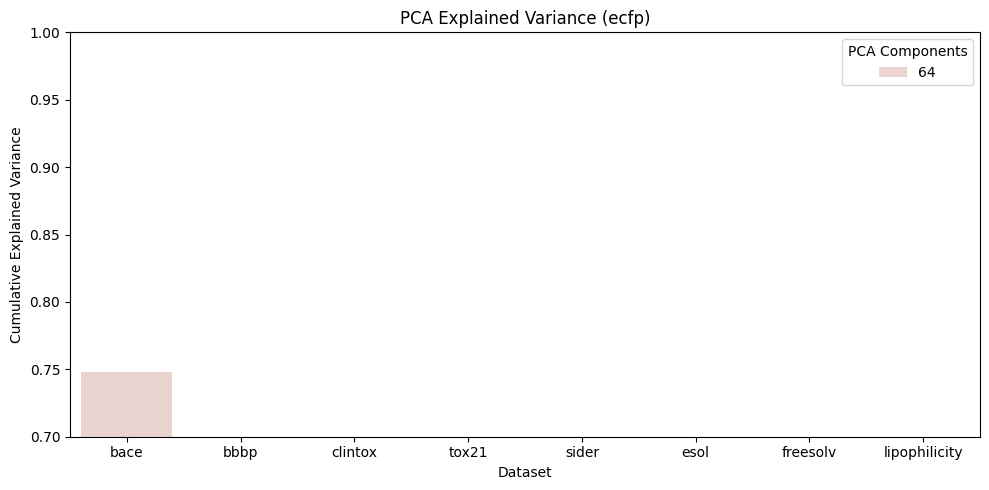

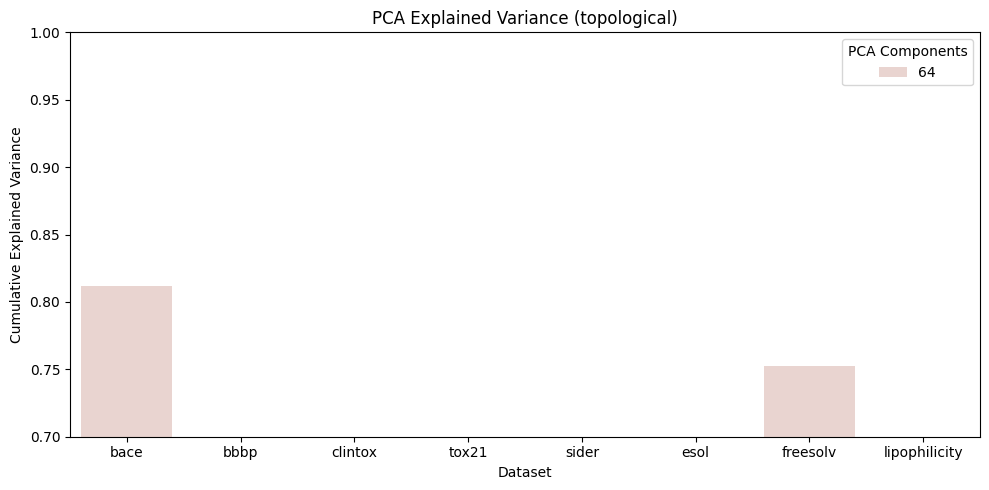

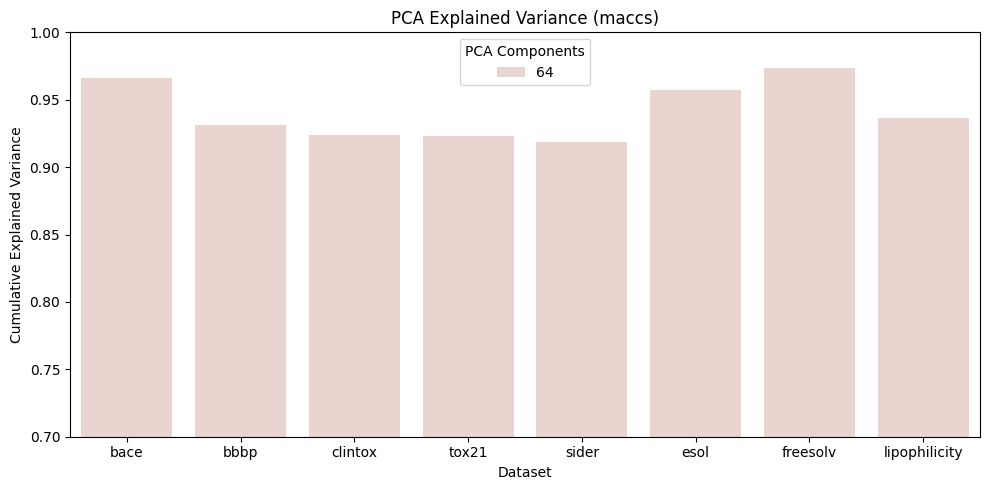

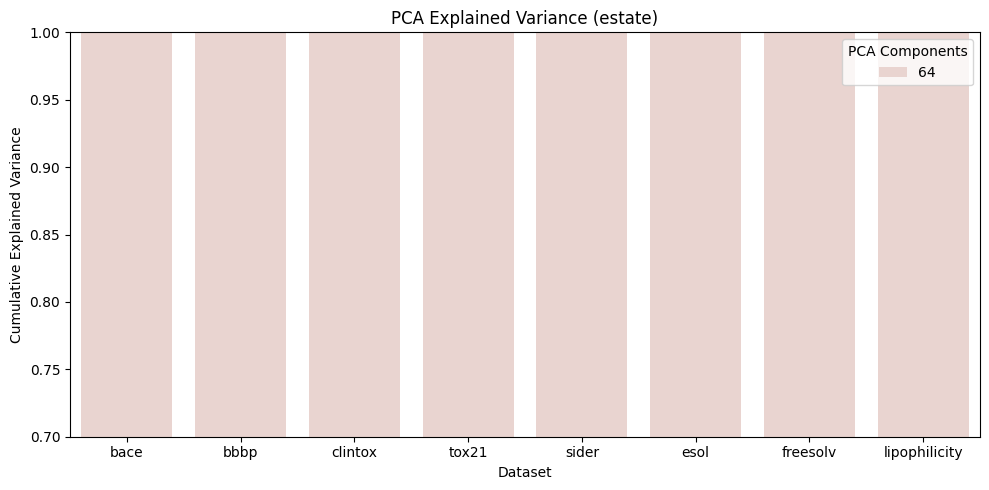

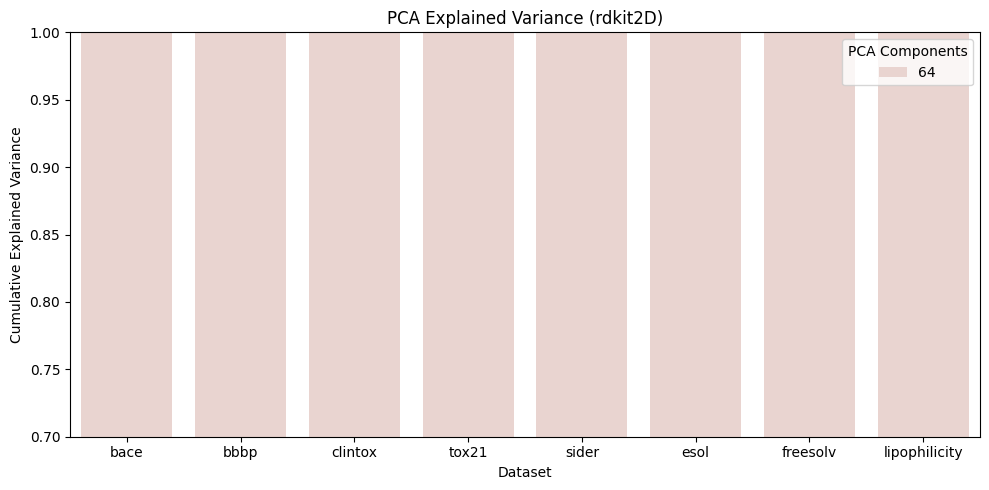

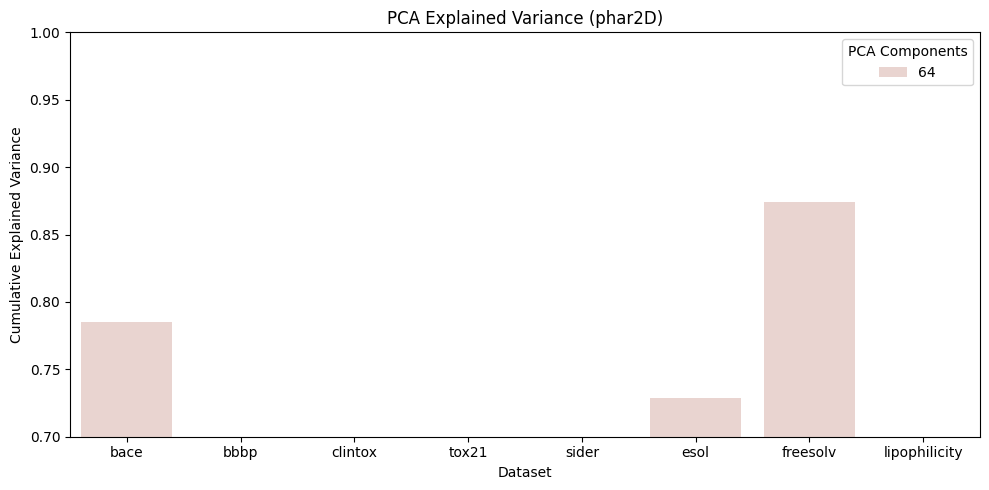

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("PCA_study/pca_explained_variance_summary.csv")

fingerprints = [
    "ecfp_var",
    "topological_var",
    "maccs_var",
    "estate_var",
    "rdkit2D_var",
    "phar2D_var"
]

for fp in fingerprints:
    
    plt.figure(figsize=(10,5))
    
    sns.barplot(
        data=df,
        x="dataset",
        y=fp,
        hue="components"
    )

    plt.ylabel("Cumulative Explained Variance")
    plt.xlabel("Dataset")
    plt.title(f"PCA Explained Variance ({fp.replace('_var','')})")
    
    plt.ylim(0.7,1.0)
    
    plt.legend(title="PCA Components")
    
    plt.tight_layout()
    plt.show()


## Heatmap 

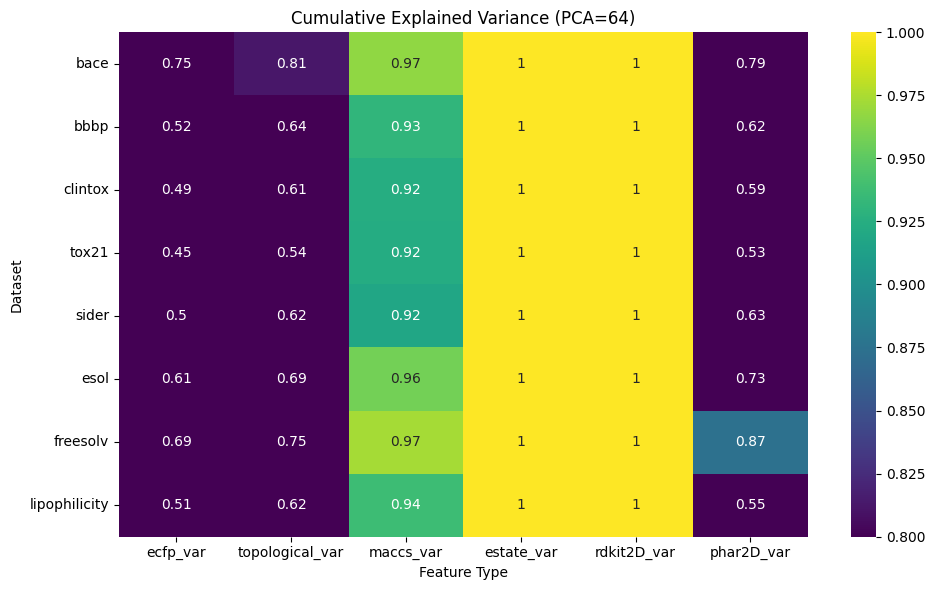

In [9]:
df64 = df[df["components"] == 64]

heatmap_data = df64.set_index("dataset")[
    [
        "ecfp_var",
        "topological_var",
        "maccs_var",
        "estate_var",
        "rdkit2D_var",
        "phar2D_var"
    ]
]

plt.figure(figsize=(10,6))

sns.heatmap(
    heatmap_data,
    annot=True,
    cmap="viridis",
    vmin=0.8,
    vmax=1.0
)

plt.title("Cumulative Explained Variance (PCA=64)")
plt.ylabel("Dataset")
plt.xlabel("Feature Type")

plt.tight_layout()
plt.show()


## Sensitivity Plot

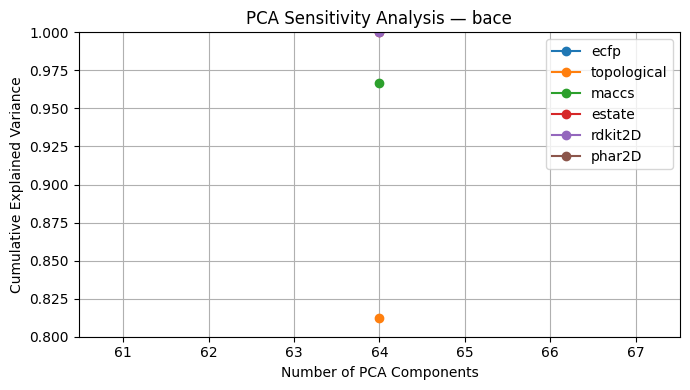

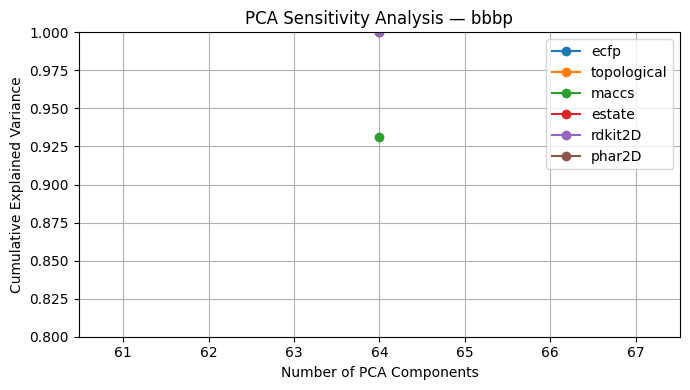

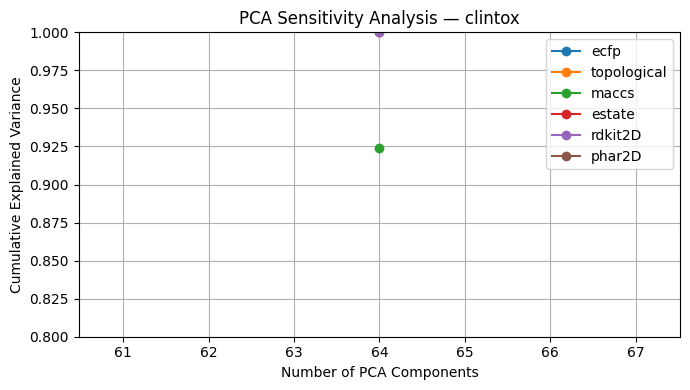

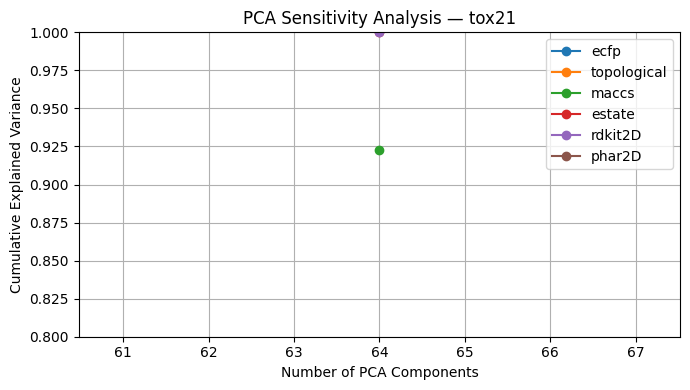

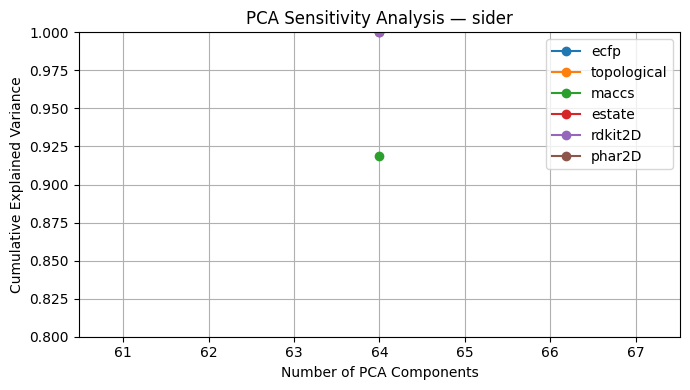

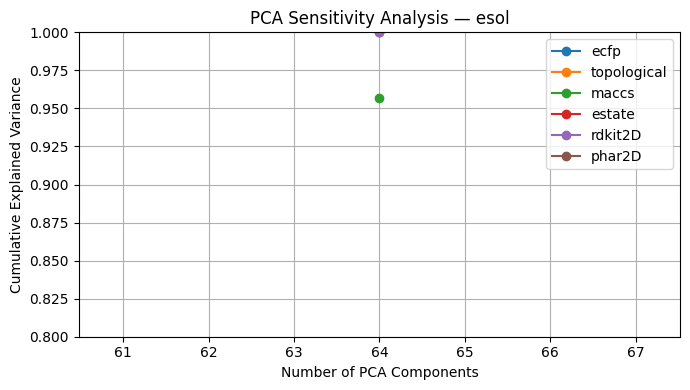

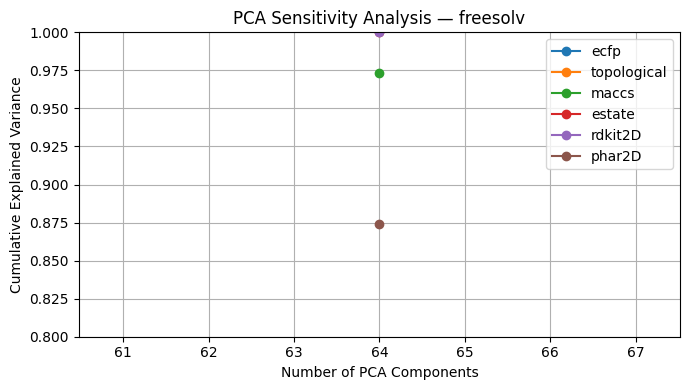

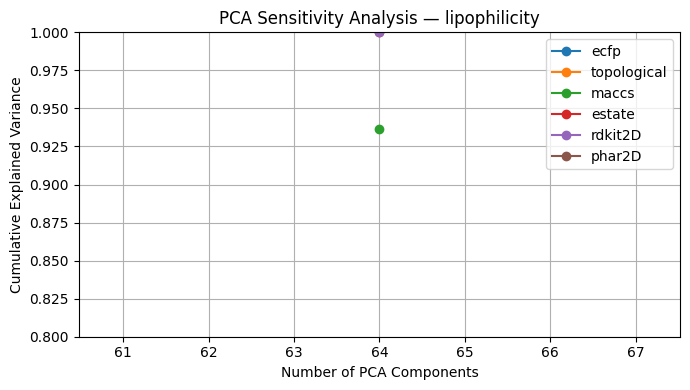

In [10]:
fingerprints = [
    "ecfp_var",
    "topological_var",
    "maccs_var",
    "estate_var",
    "rdkit2D_var",
    "phar2D_var"
]

for dataset in df["dataset"].unique():

    subset = df[df["dataset"] == dataset]

    plt.figure(figsize=(7,4))

    for fp in fingerprints:
        plt.plot(
            subset["components"],
            subset[fp],
            marker='o',
            label=fp.replace("_var","")
        )

    plt.title(f"PCA Sensitivity Analysis — {dataset}")
    plt.xlabel("Number of PCA Components")
    plt.ylabel("Cumulative Explained Variance")
    plt.ylim(0.8,1.0)

    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.show()


In [11]:
df = pd.read_csv("PCA_study/pca_explained_variance_summary.csv")

# میانگین variance تمام feature ها
df["mean_variance"] = df[
    [
        "ecfp_var",
        "topological_var",
        "maccs_var",
        "estate_var",
        "rdkit2D_var",
        "phar2D_var"
    ]
].mean(axis=1)

df


,dataset,components,ecfp_var,topological_var,maccs_var,estate_var,rdkit2D_var,phar2D_var,mean_variance
0,bace,64,0.748350,0.812084,0.966482,1.0,0.999982,0.785105,0.885334
1,bbbp,64,0.521222,0.642292,0.931200,1.0,0.999970,0.617243,0.785321
2,clintox,64,0.485772,0.610827,0.924192,1.0,0.999973,0.592874,0.768940
3,tox21,64,0.453917,0.541129,0.922875,1.0,0.999989,0.532658,0.741761
4,sider,64,0.504268,0.622369,0.918697,1.0,0.999997,0.630777,0.779351
5,esol,64,0.605063,0.690494,0.957092,1.0,0.999968,0.728535,0.830192
6,freesolv,64,0.687703,0.752671,0.973331,1.0,0.999991,0.874043,0.881290
7,lipophilicity,64,0.507802,0.624379,0.936791,1.0,0.999968,0.546322,0.769210


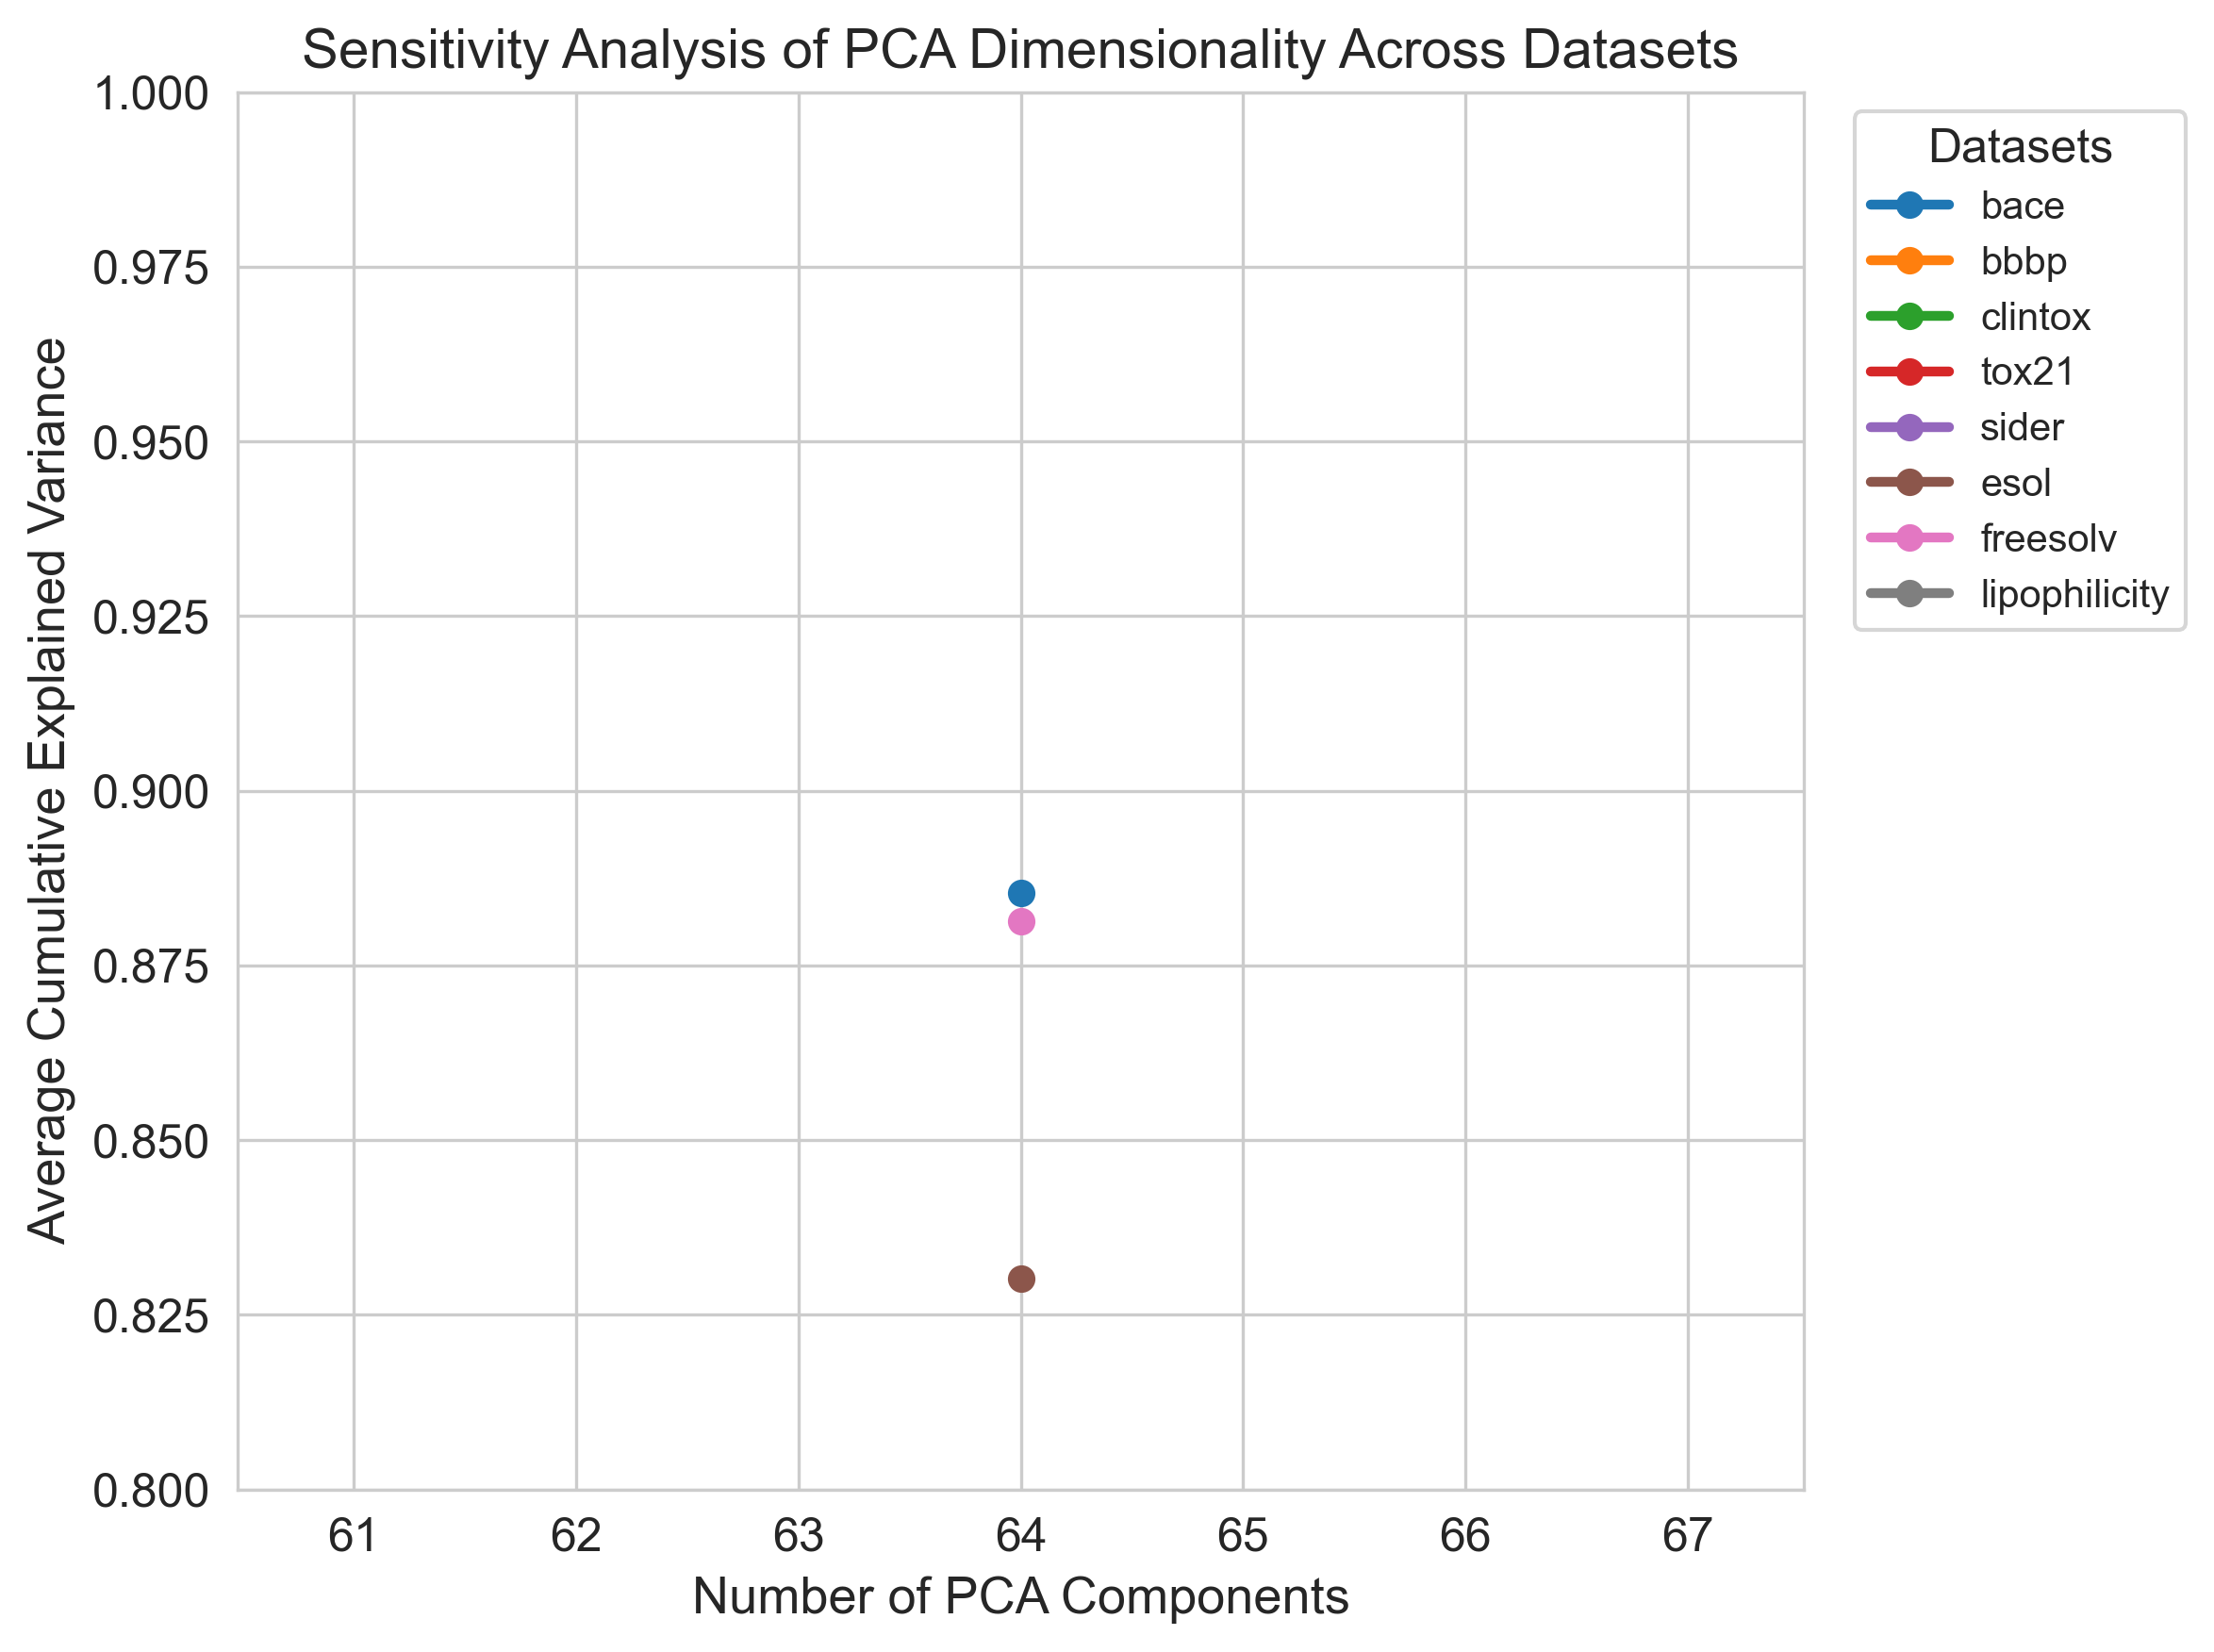

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# style مناسب مقاله
sns.set_style("whitegrid")
plt.rcParams.update({
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 13,
    "legend.fontsize": 10,
    "figure.dpi": 300
})

df = pd.read_csv("PCA_study/pca_explained_variance_summary.csv")

# میانگین variance تمام feature ها
df["mean_variance"] = df[
    [
        "ecfp_var",
        "topological_var",
        "maccs_var",
        "estate_var",
        "rdkit2D_var",
        "phar2D_var"
    ]
].mean(axis=1)

datasets = df["dataset"].unique()

# palette حرفه‌ای
colors = sns.color_palette("tab10", len(datasets))

plt.figure(figsize=(8,6))

for i, dataset in enumerate(datasets):

    subset = df[df["dataset"] == dataset]

    plt.plot(
        subset["components"],
        subset["mean_variance"],
        marker="o",
        linewidth=2.5,
        markersize=6,
        color=colors[i],
        label=dataset
    )

plt.xlabel("Number of PCA Components")
plt.ylabel("Average Cumulative Explained Variance")

plt.title("Sensitivity Analysis of PCA Dimensionality Across Datasets")

plt.ylim(0.8, 1.0)

plt.legend(
    title="Datasets",
    bbox_to_anchor=(1.02,1),
    loc="upper left"
)

plt.tight_layout()

# ذخیره برای مقاله
plt.savefig("PCA_study/PCA_sensitivity_analysis.pdf", bbox_inches="tight")
plt.savefig("PCA_study/PCA_sensitivity_analysis.png", dpi=600, bbox_inches="tight")

plt.show()